In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

In [2]:
# Load the cleaned and balanced Yelp dataset.

input_path = "../data/processed/yelp_balanced_150k_cleaned.csv"

df = pd.read_csv(input_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (150000, 6)


In [3]:
# X contains the cleaned review text.
# y contains the sentiment labels.

X = df["cleaned_text"]

y = df["sentiment"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150000,)
y shape: (150000,)


In [4]:
# Split the dataset into training and testing sets.
# Stratification ensures that the class distribution
# remains balanced in both sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120000
Testing samples: 30000


In [5]:
# Create the TF-IDF vectorizer.

tfidf_vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

print("TF-IDF vectorizer created.")

TF-IDF vectorizer created.


In [6]:
# Fit the TF-IDF vectorizer ONLY on the training data.
# This prevents data leakage.

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

print("Training TF-IDF shape:", X_train_tfidf.shape)

Training TF-IDF shape: (120000, 50000)


In [7]:
# Transform the test data using the vocabulary
# learned from the training data.

X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Testing TF-IDF shape:", X_test_tfidf.shape)

Testing TF-IDF shape: (30000, 50000)


In [8]:
# Create the Multinomial Naive Bayes classifier.

nb_model = MultinomialNB()

print("Multinomial Naive Bayes model created.")

Multinomial Naive Bayes model created.


In [10]:
# Train the Multinomial Naive Bayes model
# using the TF-IDF training data.

nb_model.fit(
    X_train_tfidf,
    y_train
)

print("Multinomial Naive Bayes model trained successfully.")

Multinomial Naive Bayes model trained successfully.


In [11]:
# Use the trained model to predict sentiment
# for the unseen test data.

y_pred_nb = nb_model.predict(
    X_test_tfidf
)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_nb))

Predictions generated successfully.
Number of predictions: 30000


In [12]:
# Calculate the overall accuracy of the model.

nb_accuracy = accuracy_score(
    y_test,
    y_pred_nb
)

print(
    "Naive Bayes Accuracy:",
    nb_accuracy
)

Naive Bayes Accuracy: 0.8207666666666666


In [17]:
# Calculate precision, recall, and F1-score.

nb_precision = precision_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

nb_recall = recall_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

nb_f1 = f1_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

print("Naive Bayes Performance")
print("-"*29)

print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1-Score :", nb_f1)

Naive Bayes Performance
-----------------------------
Accuracy : 0.8207666666666666
Precision: 0.8245150374603653
Recall   : 0.8207666666666666
F1-Score : 0.8218401806556178


In [18]:
# Generate a detailed classification report.

nb_classification_report = classification_report(
    y_test,
    y_pred_nb
)

print("Classification Report - Multinomial Naive Bayes")
print()
print(nb_classification_report)

Classification Report - Multinomial Naive Bayes

              precision    recall  f1-score   support

    Negative       0.84      0.85      0.84     10000
     Neutral       0.74      0.80      0.77     10000
    Positive       0.89      0.82      0.85     10000

    accuracy                           0.82     30000
   macro avg       0.82      0.82      0.82     30000
weighted avg       0.82      0.82      0.82     30000



In [19]:
# Generate the confusion matrix.

cm_nb = confusion_matrix(
    y_test,
    y_pred_nb,
    labels=["Negative", "Neutral", "Positive"]
)

print("Confusion Matrix:")
print(cm_nb)

Confusion Matrix:
[[8451 1426  123]
 [1126 7971  903]
 [ 440 1359 8201]]


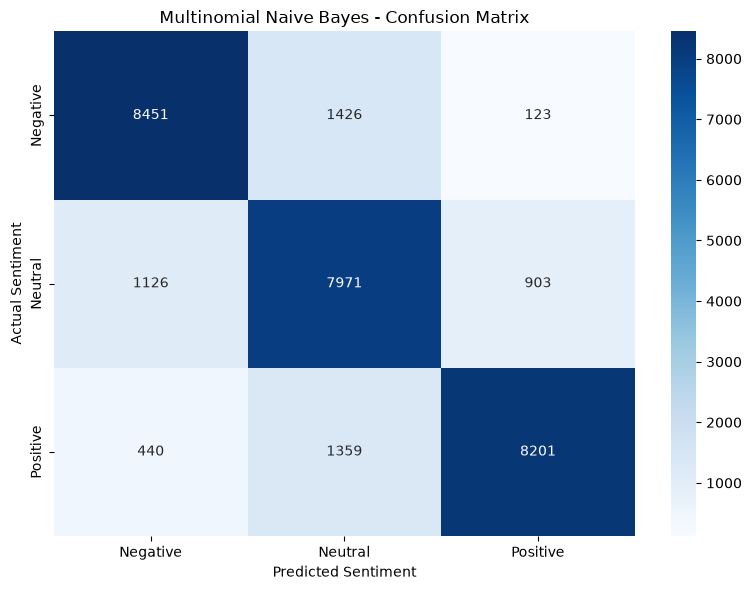

In [21]:
# Plot the confusion matrix.

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Multinomial Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.tight_layout()
plt.savefig(
    "../images/naive_bayes_confusion_matrix.png",
    dpi=300
)

plt.show()

In [22]:
# Store the Naive Bayes evaluation metrics in a DataFrame.

nb_results = pd.DataFrame({
    "Model": ["Multinomial Naive Bayes"],
    "Accuracy": [nb_accuracy],
    "Precision": [nb_precision],
    "Recall": [nb_recall],
    "F1_Score": [nb_f1]
})

nb_results

,Model,Accuracy,Precision,Recall,F1_Score
0,Multinomial Naive Bayes,0.820767,0.824515,0.820767,0.82184


In [23]:
nb_results.to_csv(
    "../results/naive_bayes_results.csv",
    index=False
)

print("Naive Bayes results saved successfully.")

Naive Bayes results saved successfully.


In [24]:
joblib.dump(
    nb_model,
    "../models/multinomial_naive_bayes.pkl"
)

print("Naive Bayes model saved successfully.")

Naive Bayes model saved successfully.


In [25]:
# Save the fitted TF-IDF vectorizer.

joblib.dump(
    tfidf_vectorizer,
    "../models/tfidf_vectorizer.pkl"
)

print("TF-IDF vectorizer saved successfully.")

TF-IDF vectorizer saved successfully.


In [26]:
# Final verification of the Naive Bayes pipeline.

print(" NAIVE BAYES FINAL RESULTS ")

print("\nDataset size:", len(df))

print("\nTraining samples:", X_train_tfidf.shape[0])
print("Testing samples:", X_test_tfidf.shape[0])

print("\nNumber of TF-IDF features:", X_train_tfidf.shape[1])

print("\nAccuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1-Score :", nb_f1)

print("\nModel training and evaluation completed successfully.")

 NAIVE BAYES FINAL RESULTS 

Dataset size: 150000

Training samples: 120000
Testing samples: 30000

Number of TF-IDF features: 50000

Accuracy : 0.8207666666666666
Precision: 0.8245150374603653
Recall   : 0.8207666666666666
F1-Score : 0.8218401806556178

Model training and evaluation completed successfully.
